<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [2]:
#ваш код здесь
data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/dst-3.0_16_1_hh_database.csv', sep = ';')
df = data.copy()
display(df.shape)

(44744, 12)

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [3]:
v1=data.head(2) 
v2= data.tail(2)
print(v1.info())
print(v2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     2 non-null      object
 1   ЗП                               2 non-null      object
 2   Ищет работу на должность:        2 non-null      object
 3   Город, переезд, командировки     2 non-null      object
 4   Занятость                        2 non-null      object
 5   График                           2 non-null      object
 6   Опыт работы                      2 non-null      object
 7   Последнее/нынешнее место работы  2 non-null      object
 8   Последняя/нынешняя должность     2 non-null      object
 9   Образование и ВУЗ                2 non-null      object
 10  Обновление резюме                2 non-null      object
 11  Авто                             2 non-null      object
dtypes: object(12)
memory usage: 324.0+ bytes

3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

4. Обратите внимание на информацию о числе непустых значений.

In [4]:

print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

В информации об резюме указано 44744 строк, 12 столбцов, вес файла 4.1+ MB.
В строке "Опыт работы" указано 44576 строк, где 168 не сообщили об их опыте работы.
В строке "Последнее/нынешнее место работы" указано 44743 строк, где 1 не сообщил об их Последнем/нынешнем место работы.
В строке "Последняя/нынешняя должность" указано 44742 строк, где 2 не сообщили об их Последней/нынешней должности.

5. Выведите основную статистическую информацию о столбцах.


In [5]:
print(data['Ищет работу на должность:'].describe())

count                       44744
unique                      14929
top       Системный администратор
freq                         3099
Name: Ищет работу на должность:, dtype: object


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [6]:
def level_education(education):
   
   words = ' '.join(education.split(' ')[:3])
   
    # Проверяем первые два слова и возвращаем соответствующий уровень
   if 'Высшее' in words:
      return 'Высшее'
   elif 'Среднее специальное' in words:
      return 'Среднее специальное'
   elif 'Неоконченное высшее' in words:
      return 'Неоконченное высшее'
   elif 'Среднее' in words:
    return 'Cреднее'
   
if 'Образование и ВУЗ' in data.columns:
    data['Образование'] = data['Образование и ВУЗ'].apply(level_education)  # Присвоение колонки данных 'Образование и ВУЗ'
    data = data.drop('Образование и ВУЗ', axis=1)   # Удаляем столбец 'Образование и ВУЗ'
  
# Уникальные 4 категории
unique_categories = data['Образование'].unique()
print("Уникальные категории образования:", unique_categories)



# Поиск кол-во встречаемых значений 'Среднее' в Объекте DataFrame
count_middle = (data['Образование']).value_counts()
print("Количество категории 'Среднее':", count_middle.iloc[3])

Уникальные категории образования: ['Неоконченное высшее' 'Высшее' 'Среднее специальное' 'Cреднее']
Количество категории 'Среднее': 559


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [7]:

def get_gender(val: str) -> str:
   if 'Мужчина' in val:
      return 'М'
   if 'Женщина' in val:
      return 'Ж'
   
def get_age(val: int) -> int:
   age_splitted = val.split(' ')
   year_words=['год', 'года', 'лет']
   for index, item in enumerate (age_splitted):
      if item in year_words:
         return int(age_splitted[index-1])



# Инициализация новых Признаков 
data['Пол'] = data["Пол, возраст"].apply(get_gender)
data['Возраст'] = data["Пол, возраст"].apply(get_age)

# Статистический Показатель
stus_g = round(data['Пол'].value_counts(normalize= True)['Ж'] * 100, 2)
stus_a = round(data['Возраст'].mean(), 2)
print('Процентов женских резюме на платформе HeadHunter :',stus_g)
print('Средний  возраст пользователей :',stus_a)

Процентов женских резюме на платформе HeadHunter : 19.07
Средний  возраст пользователей : 32.2


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [8]:

def work_xp(xp):
   if xp is np.nan or xp == 'Не указано':
        return None
   xp_splitted = xp.split(' ')[:7]
   year = 0 
   months = 0
   year_words=['год', 'года', 'лет']
   month_words=['месяца', 'месяц', 'месецев']  
   for index, item in enumerate (xp_splitted):
      # Если слово - это год, добавляем месяцы
      if item in year_words:
         year = int(xp_splitted[index-1])
      # Если слово - это месяц, добавляем месяцы
      if item in month_words:
         months = int(xp_splitted[index-1])
          
   #Вывод
   return int(year*12 + months)
      
data['Опыт работы (месяц)'] = data['Опыт работы'].apply(work_xp)  
data = data.drop('Опыт работы', axis=1)
    
# Вычисляем медиану
print(round(data['Опыт работы (месяц)'].median()))




96


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [9]:
def get_city(arg):
    million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород',
                      'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 
                      'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград'
                     ]
    city = arg.split(' , ')[0]
    if (city == 'Москва') or (city == 'Санкт-Петербург'):
        return city
    elif city in million_cities:
        return 'город миллионник'
    else:
        return 'другие'
    
def get_ready_to_move(arg):
    if ('не готов к переезду' in arg) or ('не готова к переезду' in arg):
        return False
    elif 'хочу' in arg:
        return True
    else:
        return True
    
def get_ready_for_bisiness_trips(arg):
    if ('командировка' in arg):
        if ('не готов к командировкам' in arg) or('не готова к командировкам' in arg):
            return False
        else: 
            
            return True
    else:
        return False
   

                
# Применяем функцию к DataFrame
data['Город'] = data['Город, переезд, командировки'].apply(get_city)
data['Готовность к переезду'] = data['Город, переезд, командировки'].apply(get_ready_to_move)
data['Готовность к командировкам'] = data['Город, переезд, командировки'].apply(get_ready_for_bisiness_trips)
data = data.drop('Город, переезд, командировки', axis=1)

# Вывод 
mask_1 = round(data['Город'].value_counts(normalize=True)['Санкт-Петербург'] * 100)
mask_2 = round(data[data['Готовность к переезду'] & data['Готовность к командировкам']].shape[0] / df.shape[0] *100)
print(f'Проценты соискателей из Санкт-Петербурга: {mask_1}%') 
print(f'Проценты соискателей готовые и переездам и командировкам: {mask_2}%')
            
      

Проценты соискателей из Санкт-Петербурга: 11%
Проценты соискателей готовые и переездам и командировкам: 32%


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [10]:
# Определение списков
employments = ['полная занятость', 'частичная занятость',
              'проектная работа', 'волонтерство', 'стажировка']
charts = ['полный день', 'сменный график', 
         'гибкий график', 'удаленная работа',
         'вахтовый метод']
# Создание новых столбцов в DataFrame
def check_employment(x):
    return employment in x
def check_chart(x):
   return chart in x
for employment, chart in zip(employments, charts): # zip - объединение элементов нескольких  интерируемых строк - столбцов в пары
    data[employment] = data['Занятость'].apply(check_employment) # Создаем столбцецы видов занятости 
    data[chart] = data['График'].apply(check_chart) # Создаем столбцецы видов графиков

# Удаление старых столбцов
data = data.drop('Занятость', axis=1)
data = data.drop('График', axis=1)
# Подсчет записей
mask_1 = data[data['проектная работа'] & data['волонтерство']].shape[0]
mask_2 = data[data['вахтовый метод'] & data['гибкий график']].shape[0]
print(f'Людей ищут проектную работу и волонтерство: {mask_1}')
print(f'Людей, которые хотят работать вахтовым методом и с гибким графиком: {mask_2}')

Людей ищут проектную работу и волонтерство: 436
Людей, которые хотят работать вахтовым методом и с гибким графиком: 2311


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [11]:
def get_calary(salar):
    salary = float(salar.split(' ')[0])
    return salary
def det_calary_currency(salar):
    currency_dict = {
        'грн': 'UAH', 'USD': 'USD', 'EUR': 'EUR', 'белруб': 'BYN',
        'KGS': 'KGS', 'сум': 'UZS', 'AZN': 'AZN', 'KZT': 'KZT'
    }
    curr = salar.split(' ')[1].replace('.', '')
    if curr == 'руб':
        return 'RUB'
    else:
        return currency_dict[curr]  

# Загрузка данных
ExchangeRates = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/ExchangeRates.csv', sep=',')
ExchangeRates = pd.DataFrame(ExchangeRates)
# Изменение даты 
ExchangeRates['date'] = pd.to_datetime(ExchangeRates['date'], format='mixed', dayfirst=True).dt.date
data['Обновление резюме'] = pd.to_datetime(data['Обновление резюме'], format='mixed').dt.date


# Добавление Столбцов ЗП (tmp) и Курс (tmp)
data['ЗП (tmp)'] = data['ЗП'].apply(get_calary)
data['Курс (tmp)'] = data['ЗП'].apply(det_calary_currency)
# Объединение DataFrame
merged = data.merge(ExchangeRates, left_on=['Курс (tmp)', 'Обновление резюме'],  
                  right_on=['currency', 'date'],  
                  how='left')
# Заполнение пропусков
merged['close'] = merged['close'].fillna(1)
merged['proportion'] = merged['proportion'].fillna(1)
# Вычисляем ЗП в руб 
data['ЗП (руб)'] = merged['close'] * data['ЗП (tmp)'] / merged['proportion']
# Удаление временных столбцов
data = data.drop(['ЗП', 'ЗП (tmp)', 'Курс (tmp)'], axis=1)
# Вывод медианы зарплаты в рублях
mask_2 = round(data['ЗП (руб)'].median() / 1000)

print(f'Медианная заработная плата соискателей: {mask_2}')

Медианная заработная плата соискателей: 59


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [12]:
#Постраение графика
fig = px.histogram(data_frame= data, x='Возраст',
    title='Распределение возраста соискателей',
    histnorm='percent',
    width=500,
    marginal='box',
    
)
# Выделение столбцов
fig.update_traces(marker=dict(line=dict(color='black', width=1)))
fig.show()


percentage = (data['Возраст'].mode()) # mode - для определниясамого частого числа

print(percentage)

0    30
Name: Возраст, dtype: int64


## На графике видно:
1) начальный диапазон графика начинается с 14 лет, что может свидетельствовать о  минимальном допусимом возрасте для подачи заяления на поиск работы в hh.ru, максимум 100 лет.
2) Основной пик (мода распределения), приходится  на возраст от 28 до 31 года( наибольший "%" пользователей имеют возраст  30 лет(6.33381 % от общ числа) - модальное число), занимая таким образом более 24.63 % всех пользователей находящихся на платформе.
3) Наибольшее число пользователей находится в дипазоне от 20 до 40 лет, график скревлен к левой стороне( 50 лет - середина) 
4) Выбросами можно назвать возраст от 10 до 14 и  от 76 до 100, так как они лежат вне диапазона основной массы возрастов

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [13]:
#Постраение графика
fig = px.histogram(data_frame= data, x='Опыт работы (месяц)',
    title='Распределение опыта работы соискателей',
    histnorm='percent',
    width=500,
    marginal='box',
    
)
# Выделение столбцов
fig.update_traces(marker=dict(line=dict(color='black', width=0.2)))
fig.show()


print(data['Опыт работы (месяц)'].mode())
print(data["Опыт работы (месяц)"].max())

up_xp = data[data['Опыт работы (месяц)'] == 1188]

# Вывод результатов
print("Соискатели с опытом работы равным 1188 месяцам:")
print(up_xp[['Ищет работу на должность:', 'Последнее/нынешнее место работы']])

0    72.0
Name: Опыт работы (месяц), dtype: float64
1188.0
Соискатели с опытом работы равным 1188 месяцам:
             Ищет работу на должность: Последнее/нынешнее место работы
40015  Системный администратор Windows                  АО ТК Горизонт


## На графике видно:
* 1) Наибольшим показателем является 1188, пользователей планирующий работать "Сисадмином". Данный показатель является выбрасом.
* 2) Мода раван 72 месяца 
* 3) График скревлен в левую часть  
* 4) График распределен не равномерно, в связи с различным опытом работы

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


In [14]:
df1 = data.copy()
df1 = df1[df1['ЗП (руб)'] < 1000000]

fig1 = px.histogram(data_frame= df1, x= 'ЗП (руб)', # Просмотр в диапазоне 1 000 000
    title='Распределение желаемой з/п соискателей до 1000000',
    histnorm='percent',
    width= 500,
    marginal='box',
    )
fig1.add_annotation(
    x=70000, # Координаты X, где будет размещен текст
    y=10, # Координаты Y, где будет размещен текст
    text="Средняя зарплата", # Текст аннотации
    showarrow=True, # Показать стрелку
    arrowhead=1,              
    ax= 20, # Смещение по X стрелки
    ay=-30  # Смещение по Y стрелки
)

fig2  = px.histogram(data_frame= data, x= 'ЗП (руб)', # Просмотр графика полностью 
    title='Распределение желаемой з/п соискателей',
    histnorm='percent',
    width= 500,
    marginal='box',
    )
# Выделение столбцов
fig.update_traces(marker=dict(line=dict(color='black', width=0.2)))
fig1.show()
fig2.show()
# Определение mode
print(data['ЗП (руб)'].mode())

0    50000.0
Name: ЗП (руб), dtype: float64


### На графике видно:
1) Максимум зарплаты соискателя - 24.3М рублей
2) Наиболее встречаемая ЗП - 50000 руб
3) Выброс. По мере расмотрения графика, в зависимости от рассмотренного диапазона можно выявить явные и не явные выбросы. Если рассмотреть полноценый график по всем данным(График 2), то явными выбросами окажутся числа - 24.3М, 7.6М. При рассмотрение графика до 1М, не явными выбросами окажутся числа выше дипазона 600000k 


4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

In [15]:
df1 = data.groupby('Образование', as_index=False).agg({'ЗП (руб)': 'median'})
fig = px.pie(data_frame= df1, 
            values= 'ЗП (руб)', 
            names= 'Образование',
            width= 1000,
            height= 500,
            title = 'Зависимость медианной ЗП от уровня образования',
            color='Образование',  # Раскрашиваем по уровню образования
            color_discrete_sequence=['green','blue', 'yellow', 'red'])  # Задаем цвета)
fig.show()


### На графике видно:
1) Пользователи имеющие "Высшее образование" имеют на 50% больше заработной платы, чем пользователи окончившие, только " Среднее" образование. Есть закономерность роста от низшего к высшему.
2) Пользователи окончившие "Среднее" и "Среднее специальное" имеют в среднем одинаковую ЗП
### Вывод:
Выражена явная закономерность от категории образования. В таблице представленны результаты, которые информируют нас о редких случаях привышения уровня ЗП от представленных выше, категорий(явные исключения) образования. 

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

In [16]:
box_df = data[data['ЗП (руб)']<1e6]
fig = px.box(
    data_frame=box_df,
    x='Город',
    y='ЗП (руб)',
    title='Распределение з/п по городам',
    color='Город'
    
)
fig.show()

### На графике видно:
1) Средний показатель З/П Москвы выше, чем в остальных городах.
2) Пользователь с самой высокой З/П находится в категории "другие" с показателем 924k. Cамый низкий показатель  в столбцах  "город миллионик" и "другие" 
3) Города миллионики имеют такой же средний уровень З/П как и категория "другие"

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

In [17]:
bar_data = data.groupby(
    ['Готовность к командировкам', 'Готовность к переезду'],
    as_index=False
)['ЗП (руб)'].median()
fig = px.bar(data_frame=bar_data,
    y='ЗП (руб)',
    x='Готовность к переезду',
    barmode="group",
    color='Готовность к командировкам',
    orientation='v',
    title='Медианная з/п по готовности к командировкам/переезду'
)
fig.show()

## На графике видно:
1) Пользователи, согласные к перезду, имеют З/П выше чем не согласные.
2) Пользователи, согласные на командировки, имеют ЗП выше чем не согласные

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

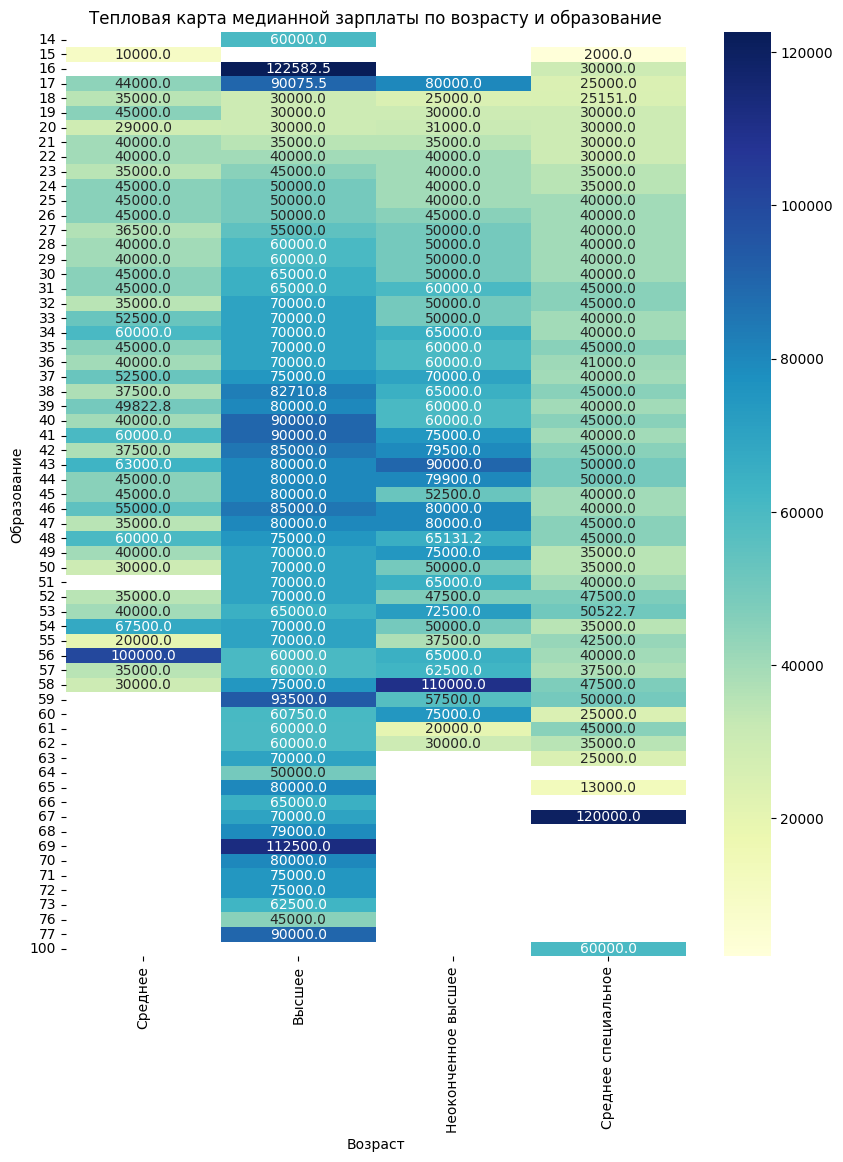

In [18]:

pivot = pd.pivot_table(
data,
index='Возраст',
values='ЗП (руб)',
columns='Образование',
aggfunc= 'median',

)

# Создание тепловой карты
plt.figure(figsize=(10, 12))  # Установка размера графика
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.1f')

# Настройка заголовка и подписей
plt.title('Тепловая карта медианной зарплаты по возрасту и образование')
plt.xlabel('Возраст')
plt.ylabel('Образование')

# Показать график
plt.show()



### На графике видно:
№Диапазон возрастов от 14 до 100
### 1. В подрастковом возрасте: 
 Исключительный заработок при низком возрасте, не свойственном для данной категории. Наличие высшего образования у лиц младше 16 лет. Из этого можно сделать вывод, что данные лица имеют исключительные навыки и специализацию или же пытаются сфабриковать данные для получение лучшего предложения от нанимателей
### 2. Распределение З/П по категория: 
### В зависимости от образования, заработок отличается у разных категорий:
 В категории "Средние" дипазон З/П отличается в большенстве случаях на пару тройку тыс в зависимости от возраста. Пользователи в данной категории перестают работать ближе к 60 годам.
 В категории "Высшее" диапазон плавно увеличивается от 14 до 100 лет. Пользователи данной категории чаще продолжают работать и в старости.
 В категории "Неоконченное и Среднее специальное" наблюдается такая же картина, как и в "Среднем", но в зависимоти от классификации образования можно наблюдать зависимость возраcта и выхода на пенсию(Чем выше образование, тем дольше люди остаются работать в старости)


8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

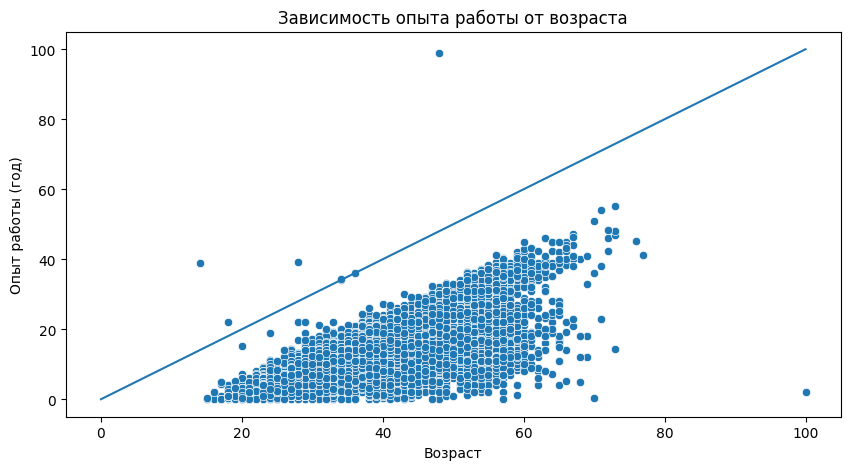

In [19]:
fig = plt.figure(figsize=(10, 5))
scatter_data = data.copy()
scatter_data['Опыт работы (год)'] = scatter_data['Опыт работы (месяц)'] / 12 
sns.lineplot(x=[0, 100], y= [0,100])
ax = sns.scatterplot(data = scatter_data, 
                     x = 'Возраст', 
                     y = 'Опыт работы (год)' )
ax.set_title('Зависимость опыта работы от возраста');



# На графике видно:
Выбросы на графике выше лини: сообщают об отдельных  пользователях, которые выходят за грань общей нормы, таких пользователей после сортировки данных убирают с общего графика

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


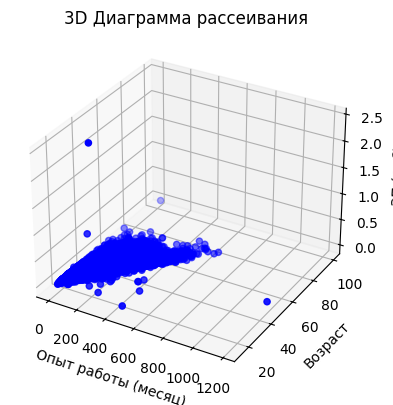

In [20]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(121, projection='3d')

x= data['Опыт работы (месяц)']
y= data['Возраст']
z= data['ЗП (руб)']
ax.scatter(x, y, z, c='b', marker='o')

# Настройка меток осей
ax.set_xlabel('Опыт работы (месяц)')
ax.set_ylabel('Возраст')
ax.set_zlabel('ЗП (руб)')
ax.set_title('3D Диаграмма рассеивания')
# Отображение графика
plt.show()
# График 2 - для отображния данных через другой визальный функционал
fig = px.scatter_3d(data_frame= data, 
                    x= data['Опыт работы (месяц)'],
                    y= data['Возраст'],
                    z= data['ЗП (руб)'],
                    log_x= True,
                    log_y= True,
                    log_z= True,
                    width= 1000,
                    height= 700)
fig.update_layout(
    scene=dict(
        xaxis_title='Опыт работы (годы)',
        yaxis_title='Возраст',
        zaxis_title='ЗП (руб)'),
    title='3D Диаграмма рассеивания')
fig.show()

### На графике видно:
Отображнение данных по трем категориям одновременно. На нем можно рассмотреть выборсы данных. Изучить основные аспекты данных, сократить написания кода. Представленны 2 экземпляра написанного кода, для визуального(график-1) и подробного анализа информации (график-2)

In [21]:
def avto(car):
    return 'автомобиль' in car.split(' ')
data['avto_car'] = data['Авто'].apply(avto)
data =  data[data['ЗП (руб)'] < 1000000]

fig = px.histogram(data, x='ЗП (руб)', color='avto_car', barmode='overlay', 
                   title='Зависимость наличия авто от ЗП',
                   width= 500,
                   labels={'avto_car': 'Наличие автомобиля'},
                   text_auto=True)  # Добавляем текст на столбцы
fig.update_layout(yaxis_title='Количество пользователей')
fig.show()

### На графике видно:
Зависимость заработной платы от наличия автомобиля. Видно, что при отсутсвии автомобиля, пользователи, чаще, получают ЗП больше, по сравнению с пользователиями имеющие автомобили. Связанно это, скорее всего, с наличием командировок и переездами пользователей в области, требующие свободные руки.  

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [22]:
duplicates = data[data.duplicated(subset=data.columns)]
data = data.drop_duplicates()
print(duplicates.shape[0])

165


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [23]:
omissions_df = data.isnull().mean()*100
omissions = data.isnull().sum()
print(omissions)
#print(omissions_df)

Пол, возраст                         0
Ищет работу на должность:            0
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Обновление резюме                    0
Авто                                 0
Образование                          0
Пол                                  0
Возраст                              0
Опыт работы (месяц)                168
Город                                0
Готовность к переезду                0
Готовность к командировкам           0
полная занятость                     0
полный день                          0
частичная занятость                  0
сменный график                       0
проектная работа                     0
гибкий график                        0
волонтерство                         0
удаленная работа                     0
стажировка                           0
вахтовый метод                       0
ЗП (руб)                             0
avto_car                             0
dtype: int64


3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [24]:
data = data.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])

data['Опыт работы (месяц)'] = data['Опыт работы (месяц)'].fillna(data['Опыт работы (месяц)'].median())
print(round(data['Опыт работы (месяц)'].mean()))

110


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [25]:
outliers = data[(data['ЗП (руб)'] > 1e6) | (data['ЗП (руб)'] < 1e3)]
data = data.drop(outliers.index)
print(outliers.shape[0])

84


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [26]:
year = data[(data['Опыт работы (месяц)']/12 >= data['Возраст'])]
data = data.drop(year.index)
print(year.shape[0])

7


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

3


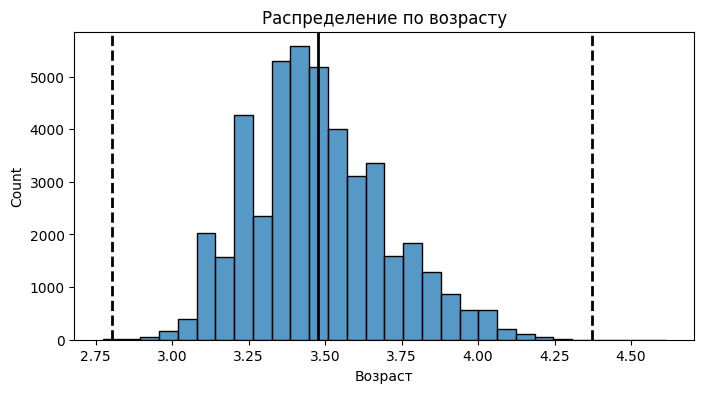

In [27]:
# Инициализация графика
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_age = np.log(data['Возраст'] + 1)
histplot = sns.histplot(log_age, bins=30, ax=ax)
# Добавление линий 
histplot.axvline(log_age.mean(), color='k', lw=2)
histplot.axvline(log_age.mean()+ 4 *log_age.std(), color='k', ls='--', lw=2)
histplot.axvline(log_age.mean()- 3 *log_age.std(), color='k', ls='--', lw=2)

histplot.set_title('Распределение по возрасту');
# Инициализация метода 3 сигм
def outliers_z_score_mod(data, feature, left=3, right=3, log_scale=False):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned
outliers, cleaned_data = outliers_z_score_mod(data, 'Возраст', left=3,  right=4, log_scale=True)

print(outliers.shape[0])

### На графике видно:
1) Распределение сдвинута от середины в левую часть график
2) Чаще всего под категорию распределения попадают люди  +3 и -3 от середнины графика. В данном распеределении количество выбросов соответствует работе метода трех сигм
